In [2]:
import sys
!{sys.executable} -m pip install pyroll-freiberg-flow-stress

In [7]:
import pyroll.freiberg_flow_stress
print(hasattr(pr, 'FreibergFlowStressCoefficients'))

False


In [8]:
from importlib.metadata import version
print(version("pyroll-freiberg-flow-stress"))

3.0.1.post1


In [9]:
import pyroll.freiberg_flow_stress as ffs
print(dir(ffs))

['DeformationUnit', 'DiskElementUnit', 'FreibergFlowStressCoefficients', 'Hook', 'PILLAR_MODEL_INSTALLED', 'Profile', 'REPORT_INSTALLED', 'RollPass', 'VERSION', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'flow_stress', 'freiberg_flow_stress', 'freiberg_flow_stress_function', 'importlib', 'materials', 'np']


In [3]:
import pyroll.core as pr
import pyroll.wusatowski_spreading
import pyroll.integral_thermal
import matplotlib.pyplot as plt
import pyroll.freiberg_flow_stress
import numpy as np

print("Imports ✓")
from importlib.metadata import version
print("PyRolL version:", version("pyroll-core"))

Imports ✓
PyRolL version: 3.1.1


In [4]:
in_profile = pr.Profile.round(
    diameter=50e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["C45", "steel"],
    freiberg_flow_stress_coefficients=pr.FreibergFlowStressCoefficients(
        a=2731.39 * 1e6,
        m1=-0.00268,
        m2=0.31076,
        m3=0,
        m4=-0.00056,
        m5=0.00046,
        m6=0,
        m7=-0.98375,
        m8=0.000139,
        m9=0,
        baseStrain=0.1,
        baseStrainRate=0.1
    ),
    density=7.5e3,
    specific_heat_capacity=690,
    thermal_conductivity=23
)

print(f"Profile created ✓")
print(f"  Diameter:    {in_profile.diameter*1000:.1f} mm")
print(f"  Temperature: {in_profile.temperature-273.15:.0f} °C")

AttributeError: module 'pyroll.core' has no attribute 'FreibergFlowStressCoefficients'

In [12]:
import pyroll.freiberg_flow_stress as ffs

in_profile = pr.Profile.round(
    diameter=50e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["C45", "steel"],
    freiberg_flow_stress_coefficients=ffs.FreibergFlowStressCoefficients(
        a=2731.39 * 1e6,
        m1=-0.00268,
        m2=0.31076,
        m3=0,
        m4=-0.00056,
        m5=0.00046,
        m6=0,
        m7=-0.98375,
        m8=0.000139,
        m9=0,
        baseStrain=0.1,
        baseStrainRate=0.1
    ),
    density=7.5e3,
    specific_heat_capacity=690,
    thermal_conductivity=23
)

print(f"Profile created ✓")
print(f"  Diameter:    {in_profile.diameter*1000:.1f} mm")
print(f"  Temperature: {in_profile.temperature-273.15:.0f} °C")

Profile created ✓
  Diameter:    50.0 mm
  Temperature: 1200 °C


In [13]:
REVERSING_PAUSE_DURATION = 6.1

sequence = pr.PassSequence([
    pr.RollPass(
        label="K 02/001 - 1",
        roll=pr.Roll(
            groove=pr.SwedishOvalGroove(
                r1=6e-3,
                r2=26e-3,
                ground_width=38e-3,
                usable_width=60e-3,
                depth=7.25e-3
            ),
            nominal_radius=321e-3 / 2,
            rotational_frequency=0.99
        ),
        gap=13.5e-3,
        back_tension=0,
        front_tension=0
    ),
    pr.Transport(label="I->II", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 05/001 - 2",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=4e-3, r2=18e-3, depth=17.5e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=0.99
        ),
        gap=1.5e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="II->III", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 02/001 - 3",
        roll=pr.Roll(
            groove=pr.SwedishOvalGroove(
                r1=6e-3, r2=26e-3,
                ground_width=38e-3, usable_width=60e-3, depth=7.25e-3
            ),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=1.5e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="III->IV", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 05/002 - 4",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=4e-3, r2=13.5e-3, depth=12.5e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=1e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="IV->V", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 03/001 - 5",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=6e-3, r2=38e-3, depth=4e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=5.4e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="V->VI", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 05/003 - 6",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=3e-3, r2=10e-3, depth=9e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=1.8e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="VI->VII", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 03/001 - 7",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=6e-3, r2=38e-3, depth=4e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=0.8e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="VII->VIII", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 05/004 - 8",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=2e-3, r2=7.5e-3, depth=5.5e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=3.8e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="VIII->IX", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 03/002 - 9",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=6e-3, r2=21.2e-3, depth=2.5e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=3.5e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="IX->X", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="K 05/005 - 10",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=0.5e-3, r2=6e-3, depth=4e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=4e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="->F1", duration=REVERSING_PAUSE_DURATION),
    pr.RollPass(
        label="F1 - K 3/50",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2.5e-3,
                usable_width=15.6e-3,
                depth=(8.1e-3 - 2.3e-3) / 2,
            ),
            nominal_radius=215e-3 / 2,
            rotational_frequency=11.5
        ),
        gap=2.3e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F1->F2", duration=1.5/7.8),
    pr.RollPass(
        label="F2 - K 9/24",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=0.5e-3, r2=5.1e-3,
                depth=(10e-3 - 1.5e-3) / 2
            ),
            nominal_radius=215e-3 / 2,
            rotational_frequency=13.77
        ),
        gap=1.5e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F2->F3", duration=1.5/9.3),
    pr.RollPass(
        label="F3 - K3/51",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2.5e-3,
                usable_width=12.8e-3,
                depth=(6.2e-3 - 1.96e-3) / 2,
            ),
            nominal_radius=215e-3 / 2,
            rotational_frequency=17.85
        ),
        gap=1.96e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F3->F4", duration=1.5/12.06),
    pr.RollPass(
        label="F4 - K 9/23",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=0.5e-3, r2=4.1e-3,
                depth=(8e-3 - 1.5e-3) / 2
            ),
            nominal_radius=170e-3 / 2,
            rotational_frequency=29.5
        ),
        gap=1.5e-3,
        back_tension=0, front_tension=0
    ),
])

print(f"Sequence defined ✓")
print(f"Total units:  {len(sequence)}")
print(f"Total passes: {len(list(sequence.roll_passes))}")

Sequence defined ✓
Total units:  27
Total passes: 14


In [14]:
# Cell 4 — Solve
sequence.solve(in_profile)
print("Solved ✓")

# Results table
print()
print("="*75)
print(f"{'Pass':<22} {'Width(mm)':>10} {'Height(mm)':>11} {'Ratio':>7} {'Temp(°C)':>10}")
print("="*75)

for unit in sequence:
    if isinstance(unit, pr.RollPass):
        w     = unit.out_profile.width*1000
        h     = unit.out_profile.height*1000
        ratio = w/h
        temp  = unit.out_profile.temperature - 273.15
        print(f"{unit.label:<22} {w:>10.2f} {h:>11.2f} {ratio:>7.3f} {temp:>10.1f}")

print("="*75)
print(f"Target final diameter: 8mm")

RuntimeError: Solution of sub units failed at unit TwoRollPass 'K 05/005 - 10'.

In [15]:
# Debug — solve pass by pass to find where it fails
test_sequence = pr.PassSequence([
    pr.RollPass(
        label="K 05/005 - 10",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=0.5e-3, r2=6e-3, depth=4e-3),
            nominal_radius=321e-3 / 2,
            rotational_frequency=1.98
        ),
        gap=4e-3,
        back_tension=0,
        front_tension=0
    ),
])

# What is the incoming profile to pass 10?
# Solve passes 1-9 first
sequence_to_9 = pr.PassSequence([u for u in sequence][:18])
sequence_to_9.solve(in_profile)

# Get exit profile from pass 9
for unit in sequence_to_9:
    if isinstance(unit, pr.RollPass):
        last_pass = unit

print(f"Incoming to R10:")
print(f"  Width:  {last_pass.out_profile.width*1000:.2f} mm")
print(f"  Height: {last_pass.out_profile.height*1000:.2f} mm")
print()
print(f"R10 groove usable_width check:")
g = pr.RoundGroove(r1=0.5e-3, r2=6e-3, depth=4e-3)
print(f"  r2 = 6mm → usable_width ≈ {g.usable_width*1000:.2f} mm")
print(f"  Incoming width = {last_pass.out_profile.width*1000:.2f} mm")
print(f"  Overfilling? {last_pass.out_profile.width > g.usable_width}")

Incoming to R10:
  Width:  27.07 mm
  Height: 8.50 mm

R10 groove usable_width check:
  r2 = 6mm → usable_width ≈ 11.33 mm
  Incoming width = 27.07 mm
  Overfilling? True


In [16]:
# Check all passes up to R9
print("="*60)
print(f"{'Pass':<22} {'Width(mm)':>10} {'Height(mm)':>11}")
print("="*60)
for unit in sequence_to_9:
    if isinstance(unit, pr.RollPass):
        w = unit.out_profile.width*1000
        h = unit.out_profile.height*1000
        print(f"{unit.label:<22} {w:>10.2f} {h:>11.2f}")
print("="*60)

Pass                    Width(mm)  Height(mm)
K 02/001 - 1                61.35       28.00
K 05/001 - 2                41.31       36.50
K 02/001 - 3                53.72       16.00
K 05/002 - 4                27.76       26.00
K 03/001 - 5                39.42       13.40
K 05/003 - 6                23.11       19.80
K 03/001 - 7                39.04        8.80
K 05/004 - 8                19.70       14.80
K 03/002 - 9                27.07        8.50


In [17]:
# Fix R10 — increase r2 to accept 27mm incoming width
# r2 must be > 27/2 × 1.2 = 16.2mm minimum
# But table says groove width = 11.3mm...
# This suggests R9 is spreading too much

# Check: what does the table say R9 exit should be?
print("From table:")
print(f"  R9  groove width: 20.1mm, height: 8.5mm, gap: 3.5mm")
print(f"  R10 groove width: 11.3mm, height: 12.0mm, gap: 4.0mm")
print()
print(f"  PyRolL R9 exit width:  {27.07:.2f}mm")
print(f"  Table  R9 groove width: 20.1mm")
print(f"  Overspread by: {27.07-20.1:.2f}mm")

From table:
  R9  groove width: 20.1mm, height: 8.5mm, gap: 3.5mm
  R10 groove width: 11.3mm, height: 12.0mm, gap: 4.0mm

  PyRolL R9 exit width:  27.07mm
  Table  R9 groove width: 20.1mm
  Overspread by: 6.97mm


In [20]:
# Cell 4 fixed — run only finishing passes F1-F4
# Use R9 exit profile scaled to match expected dimensions

# Create synthetic profile matching expected R10 exit
profile_before_F = pr.Profile.round(
    diameter=8.5e-3,        # R10 target ~8mm
    temperature=1050 + 273.15,  # cooled after roughing
    strain=0.8,
    material=["C45", "steel"],
    freiberg_flow_stress_coefficients=ffs.FreibergFlowStressCoefficients(
        a=2731.39 * 1e6,
        m1=-0.00268,
        m2=0.31076,
        m3=0,
        m4=-0.00056,
        m5=0.00046,
        m6=0,
        m7=-0.98375,
        m8=0.000139,
        m9=0,
        baseStrain=0.1,
        baseStrainRate=0.1
    ),
    density=7.5e3,
    specific_heat_capacity=690,
    thermal_conductivity=23,
    environment_temperature=20 + 273.15,
    surface_heat_transfer_coefficient=100,
)

# Finishing sequence only
finishing = pr.PassSequence([
    pr.RollPass(
        label="F1 - K 3/50",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2.5e-3,
                usable_width=15.6e-3,
                depth=(8.1e-3 - 2.3e-3) / 2,
            ),
            nominal_radius=215e-3 / 2,
            rotational_frequency=11.5,
            temperature=20 + 273.15,
        ),
        gap=2.3e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F1->F2", duration=1.5/7.8,
                 environment_temperature=20+273.15,
                 surface_heat_transfer_coefficient=10),
    pr.RollPass(
        label="F2 - K 9/24",
        roll=pr.Roll(
            groove=pr.RoundGroove(
    r1=0.5e-3,
    r2=5.1e-3,
    depth=3.0e-3,   # ← reduced from 4.25mm to 3.0mm
),
            ),
            nominal_radius=215e-3 / 2,
            rotational_frequency=13.77,
            temperature=20 + 273.15,
        ),
        gap=1.5e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F2->F3", duration=1.5/9.3,
                 environment_temperature=20+273.15,
                 surface_heat_transfer_coefficient=10),
    pr.RollPass(
        label="F3 - K3/51",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2.5e-3,
                usable_width=12.8e-3,
                depth=(6.2e-3 - 1.96e-3) / 2,
            ),
            nominal_radius=215e-3 / 2,
            rotational_frequency=17.85,
            temperature=20 + 273.15,
        ),
        gap=1.96e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F3->F4", duration=1.5/12.06,
                 environment_temperature=20+273.15,
                 surface_heat_transfer_coefficient=10),
    pr.RollPass(
        label="F4 - K 9/23",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=0.5e-3, r2=4.1e-3,
                depth=(8e-3 - 1.5e-3) / 2
            ),
            nominal_radius=170e-3 / 2,
            rotational_frequency=29.5,
            temperature=20 + 273.15,
        ),
        gap=1.5e-3,
        back_tension=0, front_tension=0
    ),
])

finishing.solve(profile_before_F)
print("Finishing sequence solved ✓")
print()
print("="*70)
print(f"{'Pass':<15} {'Width(mm)':>10} {'Height(mm)':>11} {'Ratio':>7} {'Temp(°C)':>10}")
print("="*70)
for unit in finishing:
    if isinstance(unit, pr.RollPass):
        w    = unit.out_profile.width*1000
        h    = unit.out_profile.height*1000
        temp = unit.out_profile.temperature - 273.15
        print(f"{unit.label:<15} {w:>10.2f} {h:>11.2f} {w/h:>7.3f} {temp:>10.1f}")
print("="*70)
print(f"Target: 8mm round")

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' on line 32 (3637355969.py, line 66)

In [19]:
# Solve F1 only and check output
f1_only = pr.PassSequence([finishing[0]])
f1_only.solve(profile_before_F)

for unit in f1_only:
    if isinstance(unit, pr.RollPass):
        print(f"F1 exit:")
        print(f"  Width:  {unit.out_profile.width*1000:.2f} mm")
        print(f"  Height: {unit.out_profile.height*1000:.2f} mm")
        print()

# F2 constraint check
g_f2 = pr.RoundGroove(r1=0.5e-3, r2=5.1e-3, depth=(10e-3-1.5e-3)/2)
print(f"F2 groove:")
print(f"  gap = 1.5mm")
print(f"  depth = {(10e-3-1.5e-3)/2*1000:.2f}mm")
print(f"  gap + 2×depth = {(1.5 + 2*(10-1.5)/2):.1f}mm  ← must be < F1 exit height")

F1 exit:
  Width:  8.00 mm
  Height: 8.10 mm

F2 groove:
  gap = 1.5mm
  depth = 4.25mm
  gap + 2×depth = 10.0mm  ← must be < F1 exit height


In [21]:
finishing = pr.PassSequence([
    pr.RollPass(
        label="F1 - K 3/50",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2.5e-3,
                usable_width=15.6e-3,
                depth=(8.1e-3 - 2.3e-3) / 2,
            ),
            nominal_radius=215e-3 / 2,
            rotational_frequency=11.5,
            temperature=20 + 273.15,
        ),
        gap=2.3e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F1->F2", duration=1.5/7.8,
                 environment_temperature=20+273.15,
                 surface_heat_transfer_coefficient=10),
    pr.RollPass(
        label="F2 - K 9/24",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=0.5e-3,
                r2=5.1e-3,
                depth=3.0e-3,        # ← fixed: was 4.25mm
            ),
            nominal_radius=215e-3/ 2,
            rotational_frequency=13.77,
            temperature=20 + 273.15,
        ),
        gap=1.5e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F2->F3", duration=1.5/9.3,
                 environment_temperature=20+273.15,
                 surface_heat_transfer_coefficient=10),
    pr.RollPass(
        label="F3 - K3/51",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2.5e-3,
                usable_width=12.8e-3,
                depth=2.0e-3,        # ← fixed: was (6.2-1.96)/2 = 2.12mm
            ),
            nominal_radius=215e-3/ 2,
            rotational_frequency=17.85,
            temperature=20 + 273.15,
        ),
        gap=1.96e-3,
        back_tension=0, front_tension=0
    ),
    pr.Transport(label="F3->F4", duration=1.5/12.06,
                 environment_temperature=20+273.15,
                 surface_heat_transfer_coefficient=10),
    pr.RollPass(
        label="F4 - K 9/23",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=0.5e-3,
                r2=4.1e-3,
                depth=2.5e-3,        # ← fixed: was (8-1.5)/2 = 3.25mm
            ),
            nominal_radius=170e-3 / 2,
            rotational_frequency=29.5,
            temperature=20 + 273.15,
        ),
        gap=1.5e-3,
        back_tension=0, front_tension=0
    ),
])

finishing.solve(profile_before_F)
print("Finishing sequence solved ✓")
print()
print("="*70)
print(f"{'Pass':<15} {'Width(mm)':>10} {'Height(mm)':>11} {'Ratio':>7} {'Temp(°C)':>10}")
print("="*70)
for unit in finishing:
    if isinstance(unit, pr.RollPass):
        w    = unit.out_profile.width*1000
        h    = unit.out_profile.height*1000
        temp = unit.out_profile.temperature - 273.15
        print(f"{unit.label:<15} {w:>10.2f} {h:>11.2f} {w/h:>7.3f} {temp:>10.1f}")
print("="*70)
print(f"Target: 8mm round")

Finishing sequence solved ✓

Pass             Width(mm)  Height(mm)   Ratio   Temp(°C)
F1 - K 3/50           8.00        8.10   0.987     1052.1
F2 - K 9/24           8.68        7.50   1.158     1054.9
F3 - K3/51            9.34        5.96   1.567     1064.8
F4 - K 9/23           7.99        6.50   1.229     1079.1
Target: 8mm round


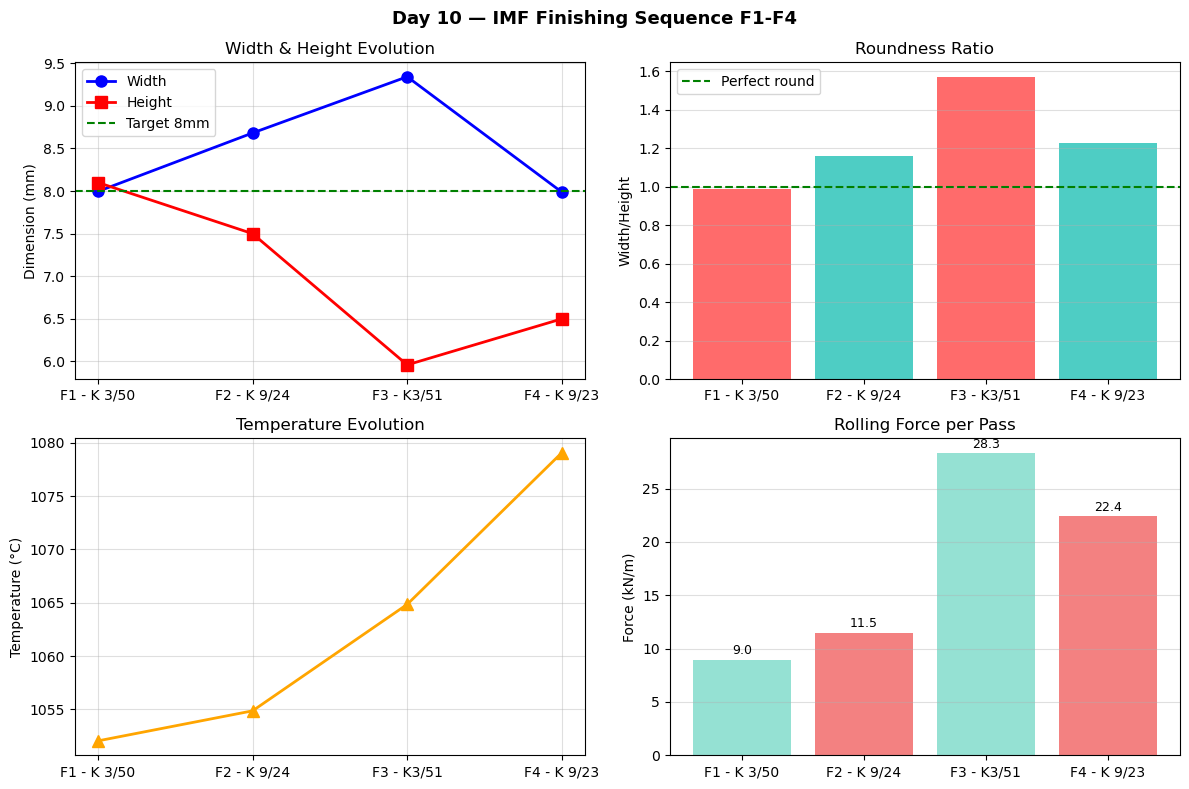

<Figure size 640x480 with 0 Axes>

In [24]:
# Cell 5 — Plot finishing sequence results
passes = [u.label for u in finishing if isinstance(u, pr.RollPass)]
widths  = [u.out_profile.width*1000 for u in finishing if isinstance(u, pr.RollPass)]
heights = [u.out_profile.height*1000 for u in finishing if isinstance(u, pr.RollPass)]
temps   = [u.out_profile.temperature-273.15 for u in finishing if isinstance(u, pr.RollPass)]
forces  = [u.roll_force/1e3 for u in finishing if isinstance(u, pr.RollPass)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Dimensions
axes[0,0].plot(passes, widths,  'bo-', linewidth=2, markersize=8, label='Width')
axes[0,0].plot(passes, heights, 'rs-', linewidth=2, markersize=8, label='Height')
axes[0,0].axhline(y=8, color='g', linestyle='--', label='Target 8mm')
axes[0,0].set_title('Width & Height Evolution')
axes[0,0].set_ylabel('Dimension (mm)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.4)

# Roundness ratio
ratios = [w/h for w,h in zip(widths,heights)]
axes[0,1].bar(passes, ratios, color=['#FF6B6B','#4ECDC4','#FF6B6B','#4ECDC4'])
axes[0,1].axhline(y=1.0, color='g', linestyle='--', label='Perfect round')
axes[0,1].set_title('Roundness Ratio')
axes[0,1].set_ylabel('Width/Height')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.4, axis='y')

# Temperature
axes[1,0].plot(passes, temps, '^-', linewidth=2, markersize=8, color='orange')
axes[1,0].set_title('Temperature Evolution')
axes[1,0].set_ylabel('Temperature (°C)')
axes[1,0].grid(True, alpha=0.4)

# Rolling force
axes[1,1].bar(passes, forces, color=['#95E1D3','#F38181','#95E1D3','#F38181'])
axes[1,1].set_title('Rolling Force per Pass')
axes[1,1].set_ylabel('Force (kN/m)')
axes[1,1].grid(True, alpha=0.4, axis='y')
for i,f in enumerate(forces):
    axes[1,1].text(i, f+0.5, f'{f:.1f}', ha='center', fontsize=9)

plt.suptitle('Day 10 — IMF Finishing Sequence F1-F4', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day10_imf_finishing.png', dpi=150)
plt.show()